In [17]:
import numpy as np
import matplotlib.pyplot as plt
from utils.data_utils import MoonsDataHelper
import warnings
from utils.evaluation_utils import EvaluationHelper
warnings.filterwarnings("ignore")

## Data Visualization

In [18]:
x_train, x_test, y_train, y_test = MoonsDataHelper.load_dataset()
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1600, 2), (400, 2), (1600,), (400,))

In [19]:
x_train.head()

,Feature_1,Feature_2
1860,1.216889,-0.627630
353,1.216012,-0.401308
1333,-0.617450,1.005901
905,1.625030,-0.216752
1289,0.798015,0.056454


In [20]:
y_train.head()

1860    1
353     1
1333    0
905     1
1289    0
Name: Class_1, dtype: int64

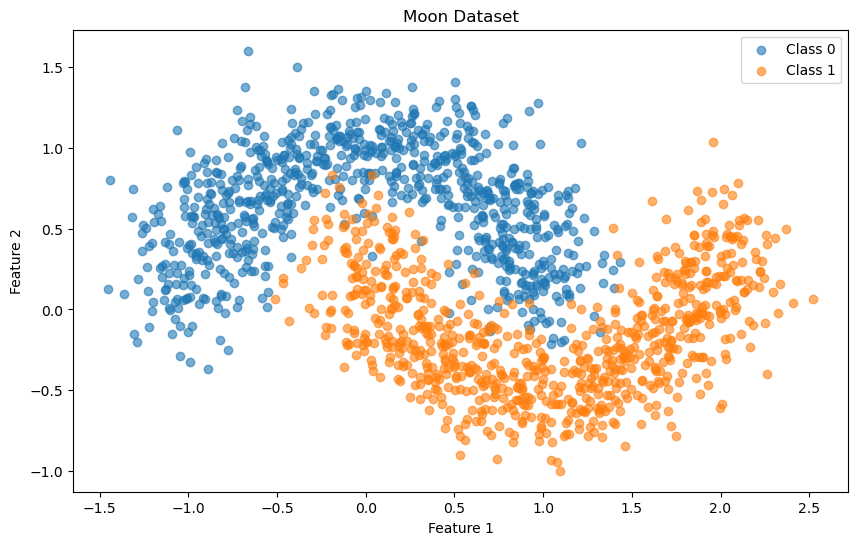

In [21]:
MoonsDataHelper.plot_moons(x_train, y_train)

## Model Training

In [22]:
x_train_np = np.array(x_train)
x_test_np = np.array(x_test)

y_train_np = np.array(y_train)
y_test_np = np.array(y_test)

In [23]:
n_features = x_train_np.shape[1]
weights = np.random.normal(0, np.sqrt(2.0 / n_features), size=(n_features))
bias = 0

weights.shape

(2,)

In [24]:
def sigmoid(linear):
    return 1 / (1 + np.exp(-linear))

In [25]:
def forward(x):
    linear = np.dot(x, weights) + bias
    return sigmoid(linear)

In [26]:
def compute_loss(y_true, prob):
    epsilon = 1e-15
    prob = np.clip(prob, epsilon, 1 - epsilon)
    loss = -(y_true * np.log(prob) + (1 - y_true) * np.log(1 - prob))
    return loss

In [27]:
def backward(x, prob, y_true, learning_rate=0.01):
    global weights, bias
    
    dw = x * (prob - y_true)
    db = prob - y_true
    
    weights -= dw * learning_rate
    bias -= db * learning_rate
    

In [28]:
epochs = 200
epoch_losses = []

learning_rate = 0.01

for epoch in range(epochs):
    total_loss = 0
    
    for idx in range(len(x_train_np)):
        prob = forward(x_train_np[idx])
        
        loss = compute_loss(y_train_np[idx], prob)
        total_loss += loss
        
        backward(x_train_np[idx], prob, y_train_np[idx], learning_rate)
    
    avg_loss = total_loss / len(x_train_np)

    epoch_losses.append(avg_loss)
    print(f"Epoch: {epoch + 1}/{epochs} | Avg. Loss: {avg_loss}")

Epoch: 1/200 | Avg. Loss: 0.6060196607314877
Epoch: 2/200 | Avg. Loss: 0.3479639871810811
Epoch: 3/200 | Avg. Loss: 0.3156023754168201
Epoch: 4/200 | Avg. Loss: 0.3015346992451496
Epoch: 5/200 | Avg. Loss: 0.29383242526315745
Epoch: 6/200 | Avg. Loss: 0.2892063687048183
Epoch: 7/200 | Avg. Loss: 0.2862733353968377
Epoch: 8/200 | Avg. Loss: 0.28434191409483817
Epoch: 9/200 | Avg. Loss: 0.2830332704802469
Epoch: 10/200 | Avg. Loss: 0.2821267307544419
Epoch: 11/200 | Avg. Loss: 0.2814876426108943
Epoch: 12/200 | Avg. Loss: 0.281030734819225
Epoch: 13/200 | Avg. Loss: 0.2807003453736759
Epoch: 14/200 | Avg. Loss: 0.2804592201401633
Epoch: 15/200 | Avg. Loss: 0.2802819020718057
Epoch: 16/200 | Avg. Loss: 0.280150691058315
Epoch: 17/200 | Avg. Loss: 0.2800530996467625
Epoch: 18/200 | Avg. Loss: 0.2799802088399181
Epoch: 19/200 | Avg. Loss: 0.27992558155453323
Epoch: 20/200 | Avg. Loss: 0.2798845305594318
Epoch: 21/200 | Avg. Loss: 0.27985361687182997
Epoch: 22/200 | Avg. Loss: 0.279830300981

In [29]:
def predict(x):
    prob = forward(x)
    return prob >= 0.5, prob

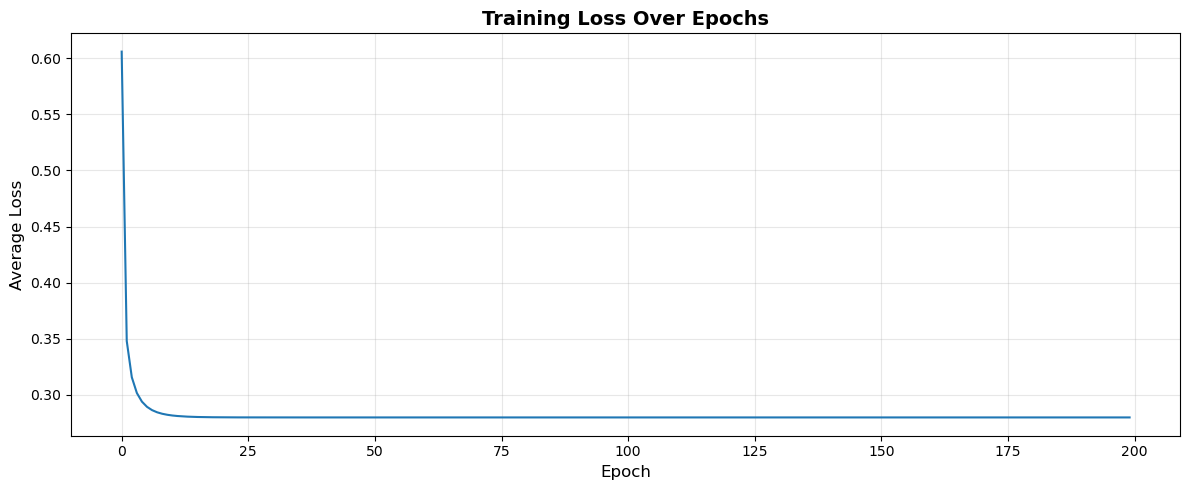

Initial loss: 0.606020
Final loss: 0.279760
Loss reduction: 53.84%


In [30]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(epoch_losses, linewidth=1.5)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Average Loss", fontsize=12)
ax.set_title("Training Loss Over Epochs", fontsize=14, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial loss: {epoch_losses[0]:.6f}")
print(f"Final loss: {epoch_losses[-1]:.6f}")
print(f"Loss reduction: {(epoch_losses[0] - epoch_losses[-1])/epoch_losses[0]*100:.2f}%")

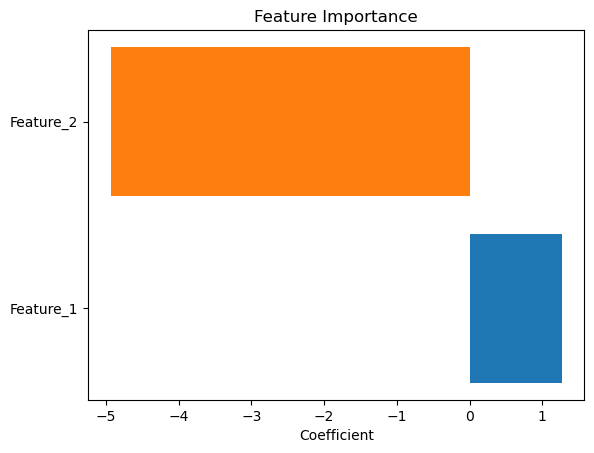

In [31]:
coefs = weights
features = np.array(x_train.columns)

idx = np.argsort(np.abs(coefs))[::-1]

plt.barh(features[idx], coefs[idx], color=["#1f77b4" if c > 0 else "#ff7f0e" for c in coefs[idx]])
plt.xlabel("Coefficient")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

## Model Evaluation

In [32]:
predictions = []
probabilities = []

for x in x_test_np:
    prediction, prob = predict(x)
    predictions.append(prediction)
    probabilities.append(prob)

predictions = np.array(predictions)
probabilities = np.array(probabilities)

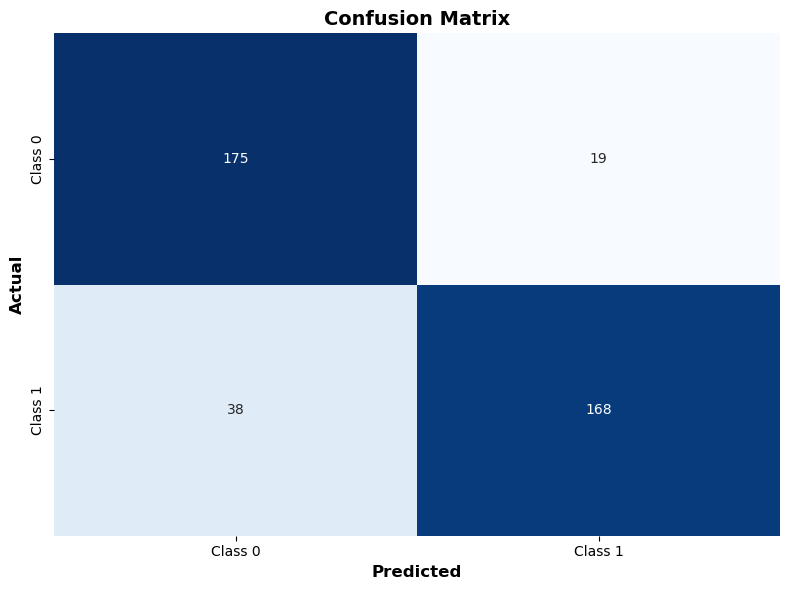

True Negatives: 175
False Positives: 19
False Negatives: 38
True Positives: 168

Sensitivity (Recall): 0.8155
Specificity: 0.9021
Precision: 0.8984
Accuracy: 0.8575
F1 Score: 0.8550


In [33]:
EvaluationHelper.plot_confusion_matrix(y_test_np, predictions, class_names=["Class 0", "Class 1"])

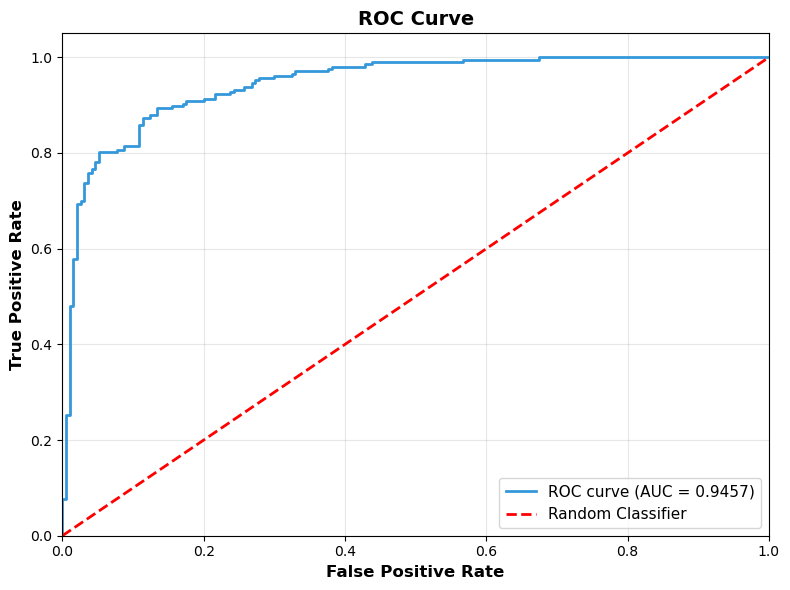

Area Under the Curve (AUC): 0.9457


In [34]:
EvaluationHelper.plot_roc_curve(y_test_np, probabilities)

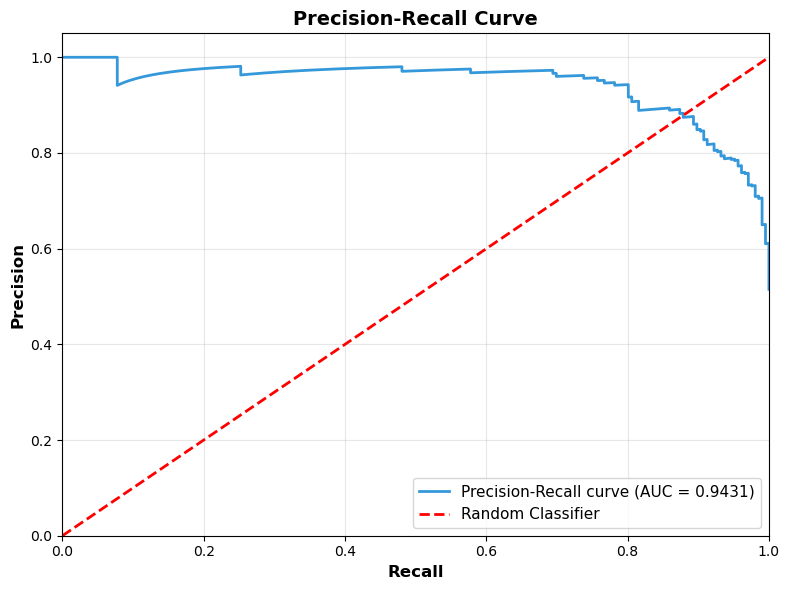

Area Under the Curve (AUC): 0.9431


In [35]:
EvaluationHelper.plot_precision_recall_curve(y_test_np, probabilities)

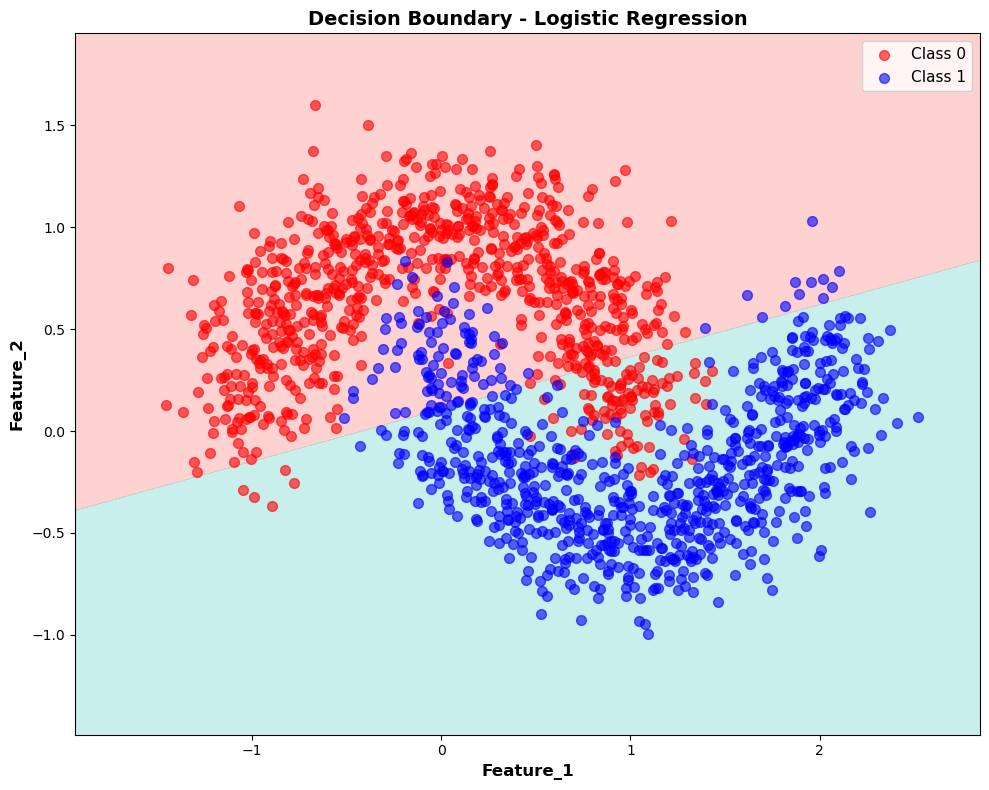

In [36]:
h = 0.02
x_min, x_max = x_test_np[:, 0].min() - 0.5, x_test_np[:, 0].max() + 0.5
y_min, y_max = x_test_np[:, 1].min() - 0.5, x_test_np[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = np.array([predict(np.array([xx[i, j], yy[i, j]]))[1]
              for i in range(xx.shape[0]) for j in range(xx.shape[1])])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, Z, alpha=0.3, levels=[0, 0.5, 1], colors=['#FF6B6B', '#4ECDC4'])
ax.scatter(x_train_np[y_train_np == 0, 0], x_train_np[y_train_np == 0, 1], 
           c='red', marker='o', label='Class 0', alpha=0.6, s=50)
ax.scatter(x_train_np[y_train_np == 1, 0], x_train_np[y_train_np == 1, 1], 
           c='blue', marker='o', label='Class 1', alpha=0.6, s=50)
ax.set_xlabel('Feature_1', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature_2', fontsize=12, fontweight='bold')
ax.set_title('Decision Boundary - Logistic Regression', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()